# Fecho Convexo 3D

| Informação  | Detalhes    |
| ----------- | ----------- |
| Disciplina  | Geometria Computacional (`INF2604`) |
| Professor   | Waldemar Celes (<celes@inf.puc-rio.br>) |
| Aluno       | Gabriel Ribeiro Gomes (<ggomes@inf.puc-rio.br>, <ribeiroggabriel@gmail.com>) |

Este notebook reimplementa e organiza o trabalho de fecho convexo em 3D, incluindo:

- Geração de nuvens de pontos tridimensionais aleatórias.
- Implementação incremental do fecho convexo 3D (algoritmo customizado).
- Comparação com a implementação `ConvexHull` da SciPy.
- Visualizações em 3D e exportação dos resultados (figuras e arquivos STL) para uma pasta datada.

## Imports e configuração global

Nesta seção centralizamos todos os imports utilizados no notebook e definimos a semente
aleatória global para garantir reprodutibilidade dos experimentos.

In [1]:
import time

from datetime import datetime
from io import StringIO
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from pydantic import BaseModel, Field
from scipy.spatial import ConvexHull


RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)  # noqa: NPY002
# Aviso `noqa: NPY002` - Replace legacy `np.random.seed` call with `np.random.Generator`
# Esse aviso vem do ruff (linter) e indica que o uso de `np.random.seed` é considerado,
# legado, sugerindo o uso de `np.random.Generator` para melhor controle da geração de
# números aleatórios. Como esse código é para fins educacionais e simples, mantive o uso
# tradicional para facilitar o entendimento.

# Deixei esse comentário aqui para explicar o motivo dos `noqa`, que podem ser ignorados
# para o propósito deste código.

## 2. Modelos de dados (Pydantic)

Aqui definimos modelos de dados usando **Pydantic** para representar:

- Pontos em 3D (`Point3D`).
- Configuração de geração de nuvem de pontos (`RandomPointCloudConfig`).
- Resultado de comparação entre o algoritmo customizado e o SciPy (`ConvexHullComparisonResult`).

Isso ajuda a documentar o formato dos dados, validar parâmetros e deixar a pipeline mais clara.

In [2]:
class Point3D(BaseModel):
    """Represents a point in 3D space."""

    x: float
    y: float
    z: float

    def as_array(self) -> np.ndarray:
        """Converts the point to a NumPy array (x, y, z).

        Returns:
            NumPy array with the point coordinates.
        """
        return np.array([self.x, self.y, self.z], dtype=float)


class RandomPointCloudConfig(BaseModel):
    """Configuration for generating random 3D point clouds."""

    num_points: int = Field(..., ge=4, description="Number of points in the cloud.")
    lower_bound: float = Field(-10.0, description="Lower bound for each coordinate.")
    upper_bound: float = Field(10.0, description="Upper bound for each coordinate.")


class ConvexHullComparisonResult(BaseModel):
    """Result of the comparison between custom convex hull and SciPy's implementation."""

    num_points: int
    num_vertices_custom: int
    num_vertices_scipy: int
    vertices_match: bool
    custom_execution_time: float
    scipy_execution_time: float

## 3. Implementação do algoritmo de fecho convexo 3D (incremental)

Nesta seção trazemos a implementação incremental do fecho convexo 3D usada no trabalho original.
Ela é responsável por construir o fecho convexo a partir de uma lista de pontos em 3D.

O código abaixo trabalha com classes auxiliares para vetores, vértices, arestas e faces.

In [3]:
# Constants used by the incremental 3D convex hull algorithm
ON_HULL: bool = True
REMOVED: bool = True
VISIBLE: bool = True
PROCESSED: bool = True


class Vector:
    """Represents a 3D vector with basic operations."""

    def __init__(self, x: float, y: float, z: float) -> None:
        self.x = x
        self.y = y
        self.z = z

    def __str__(self) -> str:
        return f"{self.x} {self.y} {self.z}"

    def __sub__(self, other: "Vector") -> "Vector":
        return Vector(other.x - self.x, other.y - self.y, other.z - self.z)

    def __add__(self, other: "Vector") -> "Vector":
        return Vector(other.x + self.x, other.y + self.y, other.z + self.z)


class Vertex:
    """Represents a vertex in the 3D convex hull with associated metadata."""

    def __init__(
        self,
        vector: Vector,
        vertex_number: int | None = None,
        duplicate: Any = None,
        on_hull: bool = False,
        mark: bool = False,
    ) -> None:
        self.vector = vector
        self.vertex_number = vertex_number
        self.duplicate = duplicate
        self.on_hull = on_hull
        self.mark = mark

    def __str__(self) -> str:
        return str(self.vector)

    @staticmethod
    def are_collinear(
        vertex_a: "Vertex", vertex_b: "Vertex", vertex_c: "Vertex"
    ) -> bool:
        """Check if three vertices are collinear."""
        return (
            (vertex_c.vector.z - vertex_a.vector.z)
            * (vertex_b.vector.y - vertex_a.vector.y)
            - (vertex_b.vector.z - vertex_a.vector.z)
            * (vertex_c.vector.y - vertex_a.vector.y)
            == 0
            and (vertex_b.vector.z - vertex_a.vector.z)
            * (vertex_c.vector.x - vertex_a.vector.x)
            - (vertex_b.vector.x - vertex_a.vector.x)
            * (vertex_c.vector.z - vertex_a.vector.z)
            == 0
            and (vertex_b.vector.x - vertex_a.vector.x)
            * (vertex_c.vector.y - vertex_a.vector.y)
            - (vertex_b.vector.y - vertex_a.vector.y)
            * (vertex_c.vector.x - vertex_a.vector.x)
            == 0
        )


class Edge:
    """Represents an edge in the 3D convex hull."""

    edge_counter = 0

    def __init__(
        self,
        adjacent_faces: list | None = None,
        endpoints: list | None = None,
        new_face: Any = None,
        delete: bool = False,
    ) -> None:
        self.adjacent_faces = adjacent_faces[:] if adjacent_faces else [None, None]
        self.endpoints = endpoints[:] if endpoints else [None, None]
        self.new_face = new_face
        self.delete = delete
        self.edge_id = Edge.edge_counter
        Edge.edge_counter += 1

    def __str__(self) -> str:
        face_nums = [
            str(face.face_number) if face is not None else "."
            for face in self.adjacent_faces
        ]
        return (
            f"edge({self.edge_id}): {self.endpoints[0]} {self.endpoints[1]} "
            f"del: {self.delete} newf: {self.new_face.face_number if self.new_face else -1} "
            f"adjf: {' '.join(face_nums)}"
        )


class Face:
    """Represents a triangular face in the 3D convex hull."""

    face_counter = 0

    def __init__(
        self,
        edges: list | None = None,
        vertices: list | None = None,
        visible: bool = False,
    ) -> None:
        self.edges = edges[:] if edges else [None, None, None]
        self.vertices = vertices[:] if vertices else [None, None, None]
        self.visible = visible
        self.face_number = Face.face_counter
        Face.face_counter += 1

    def __str__(self) -> str:
        return (
            f"facet normal 0 0 0\n"
            f"outer loop\n"
            f"vertex {self.vertices[0]}\n"
            f"vertex {self.vertices[1]}\n"
            f"vertex {self.vertices[2]}\n"
            f"endloop\n"
            f"endfacet"
        )

    def initialize_edges(self, fold_face: "Face | None" = None) -> list:
        """Initialize the edges of this face."""
        vertex_0 = self.vertices[0]
        vertex_1 = self.vertices[1]
        vertex_2 = self.vertices[2]
        new_edges = []

        if fold_face is None:
            edge_0 = Edge()
            edge_1 = Edge()
            edge_2 = Edge()
            new_edges = [edge_0, edge_1, edge_2]
        else:
            edge_0 = fold_face.edges[2]
            edge_1 = fold_face.edges[1]
            edge_2 = fold_face.edges[0]

        edge_0.endpoints[0] = vertex_0
        edge_0.endpoints[1] = vertex_1
        edge_1.endpoints[0] = vertex_1
        edge_1.endpoints[1] = vertex_2
        edge_2.endpoints[0] = vertex_2
        edge_2.endpoints[1] = vertex_0

        self.edges[0] = edge_0
        self.edges[1] = edge_1
        self.edges[2] = edge_2

        edge_0.adjacent_faces[0] = self
        edge_1.adjacent_faces[0] = self
        edge_2.adjacent_faces[0] = self

        return new_edges

    def make_counter_clockwise(self, edge: Edge, point: Vertex) -> None:
        """Make the face counter-clockwise oriented."""
        if edge.adjacent_faces[0].visible:
            face_visible = edge.adjacent_faces[0]
        else:
            face_visible = edge.adjacent_faces[1]

        vertex_index = 0
        while face_visible.vertices[vertex_index] != edge.endpoints[0]:
            vertex_index += 1

        if face_visible.vertices[(vertex_index + 1) % 3] != edge.endpoints[1]:
            self.vertices[0] = edge.endpoints[1]
            self.vertices[1] = edge.endpoints[0]
        else:
            self.vertices[0] = edge.endpoints[0]
            self.vertices[1] = edge.endpoints[1]
            self.edges[1], self.edges[2] = self.edges[2], self.edges[1]

        self.vertices[2] = point


class Hull:
    """3D Convex hull implementation using incremental algorithm."""

    def __init__(self, vectors: list) -> None:
        self.vertices: list = []
        self.edges: list = []
        self.faces: list = []
        self._read_vertices(vectors)
        vertex_index = self._create_double_triangle()
        self._construct_hull(vertex_index)
        self._order_edges_on_faces()

    def _read_vertices(self, vectors: list) -> None:
        """Read and convert vectors to vertices."""
        self.vertices = [
            Vertex(vector, vertex_index) for vertex_index, vector in enumerate(vectors)
        ]

    def _order_edges_on_faces(self) -> None:
        """Order edges correctly on faces."""
        for face in self.faces:
            for edge_index in (0, 1, 2):
                edge = face.edges[edge_index]
                vertex_current = face.vertices[edge_index]
                vertex_next = face.vertices[(edge_index + 1) % 3]

                if not (
                    (
                        (edge.endpoints[0] == vertex_current)
                        and (edge.endpoints[1] == vertex_next)
                    )
                    or (
                        (edge.endpoints[1] == vertex_current)
                        and (edge.endpoints[0] == vertex_next)
                    )
                ):
                    for other_edge_index in (0, 1, 2):
                        other_edge = face.edges[other_edge_index]
                        if (
                            (other_edge.endpoints[0] == vertex_current)
                            and (other_edge.endpoints[1] == vertex_next)
                        ) or (
                            (other_edge.endpoints[1] == vertex_current)
                            and (other_edge.endpoints[0] == vertex_next)
                        ):
                            face.edges[edge_index], face.edges[other_edge_index] = (
                                face.edges[other_edge_index],
                                face.edges[edge_index],
                            )

    def print_stl(self) -> None:
        """Print the hull in STL format."""
        print("solid points")
        for face in self.faces:
            print(face)
        print("endsolid points")

    @staticmethod
    def _volume_sign(face: "Face", point: Vertex) -> int:
        """Calculate the volume sign to determine point position relative to face."""
        vector_a = face.vertices[0].vector - point.vector
        vector_b = face.vertices[1].vector - point.vector
        vector_c = face.vertices[2].vector - point.vector

        volume = (
            vector_a.x * (vector_b.y * vector_c.z - vector_b.z * vector_c.y)
            + vector_a.y * (vector_b.z * vector_c.x - vector_b.x * vector_c.z)
            + vector_a.z * (vector_b.x * vector_c.y - vector_b.y * vector_c.x)
        )

        epsilon = 1e-10
        if volume > epsilon:
            return 1
        if volume < -epsilon:
            return -1
        return 0

    def _create_double_triangle(self) -> int:
        """Create initial double triangle from non-collinear points."""
        vertex_index_0 = 0
        num_vertices = len(self.vertices)

        while Vertex.are_collinear(
            self.vertices[vertex_index_0 % num_vertices],
            self.vertices[(vertex_index_0 + 1) % num_vertices],
            self.vertices[(vertex_index_0 + 2) % num_vertices],
        ):
            vertex_index_0 = (vertex_index_0 + 1) % num_vertices
            if vertex_index_0 == 0:
                raise Exception("DoubleTriangle: All points are collinear!")

        vertex_index_1 = (vertex_index_0 + 1) % num_vertices
        vertex_index_2 = (vertex_index_1 + 1) % num_vertices

        self.vertices[vertex_index_0].mark = PROCESSED
        self.vertices[vertex_index_1].mark = PROCESSED
        self.vertices[vertex_index_2].mark = PROCESSED

        self.faces.append(
            Face(
                vertices=[
                    self.vertices[vertex_index_0],
                    self.vertices[vertex_index_1],
                    self.vertices[vertex_index_2],
                ]
            )
        )
        face_0: Face = self.faces[-1]
        self.edges.extend(face_0.initialize_edges())

        self.faces.append(
            Face(
                vertices=[
                    self.vertices[vertex_index_2],
                    self.vertices[vertex_index_1],
                    self.vertices[vertex_index_0],
                ]
            )
        )
        face_1: Face = self.faces[-1]
        self.edges.extend(face_1.initialize_edges(face_0))

        face_0.edges[0].adjacent_faces[1] = face_1
        face_0.edges[1].adjacent_faces[1] = face_1
        face_0.edges[2].adjacent_faces[1] = face_1
        face_1.edges[0].adjacent_faces[1] = face_0
        face_1.edges[1].adjacent_faces[1] = face_0
        face_1.edges[2].adjacent_faces[1] = face_0

        vertex_index_3 = (vertex_index_2 + 1) % num_vertices
        volume = self._volume_sign(face_0, self.vertices[vertex_index_3])

        while volume == 0:
            vertex_index_3 = (vertex_index_3 + 1) % num_vertices
            if vertex_index_3 == 0:
                raise Exception("All points are coplanar (same plane)!")
            volume = self._volume_sign(face_0, self.vertices[vertex_index_3])

        return vertex_index_3

    def _construct_hull(self, vertex_index: int) -> None:
        """Construct the convex hull incrementally."""
        initial_vertex_index = vertex_index

        while True:
            if not self.vertices[vertex_index].mark:
                self.vertices[vertex_index].mark = PROCESSED
            self._add_one_point(self.vertices[vertex_index])
            initial_vertex_index, vertex_index = self._cleanup(
                initial_vertex_index, vertex_index
            )
            if vertex_index == initial_vertex_index:
                break

    def _add_one_point(self, point: Vertex) -> bool:
        """Add one point to the current hull."""
        is_visible = False

        for face in self.faces:
            volume = self._volume_sign(face, point)
            if volume < 0:
                face.visible = VISIBLE
                is_visible = True

        if not is_visible:
            point.on_hull = not ON_HULL
            return False

        for edge in self.edges:
            if edge.adjacent_faces[0].visible and edge.adjacent_faces[1].visible:
                edge.delete = REMOVED
            elif edge.adjacent_faces[0].visible or edge.adjacent_faces[1].visible:
                edge.new_face = self._make_cone_face(edge, point)

        return True

    def _make_cone_face(self, edge: Edge, point: Vertex) -> "Face":
        """Create a new cone face."""
        new_edges = [None, None]

        for endpoint_index in (0, 1):
            duplicate_edge = edge.endpoints[endpoint_index].duplicate
            if duplicate_edge is None:
                new_edges[endpoint_index] = Edge(
                    endpoints=[edge.endpoints[endpoint_index], point]
                )
                edge.endpoints[endpoint_index].duplicate = new_edges[endpoint_index]
                self.edges.append(new_edges[endpoint_index])
            else:
                new_edges[endpoint_index] = duplicate_edge

        new_face = Face(edges=[edge, new_edges[0], new_edges[1]])
        self.faces.append(new_face)
        new_face.make_counter_clockwise(edge, point)

        for edge_index in (0, 1):
            for face_index in (0, 1):
                if new_edges[edge_index].adjacent_faces[face_index] is None:
                    new_edges[edge_index].adjacent_faces[face_index] = new_face
                    break

        return new_face

    def _cleanup(self, initial_vertex_index: int, vertex_index: int) -> tuple:
        """Clean up after adding a point."""
        self._clean_edges()
        self._clean_faces()
        initial_vertex_index, vertex_index = self._clean_vertices(
            initial_vertex_index, vertex_index
        )
        return initial_vertex_index, vertex_index

    def _clean_edges(self) -> list:
        """Clean up deleted edges."""
        for edge in self.edges:
            if edge.new_face:
                if edge.adjacent_faces[0].visible:
                    edge.adjacent_faces[0] = edge.new_face
                else:
                    edge.adjacent_faces[1] = edge.new_face
            edge.new_face = None

        deleted_edges = [str(edge.edge_id) for edge in self.edges if edge.delete]
        self.edges = [edge for edge in self.edges if not edge.delete]
        return deleted_edges

    def _clean_faces(self) -> None:
        """Clean up visible faces."""
        self.faces = [face for face in self.faces if not face.visible]

    def _clean_vertices(self, initial_vertex_index: int, vertex_index: int) -> tuple:
        """Clean up vertices not on hull."""
        for edge in self.edges:
            edge.endpoints[0].on_hull = ON_HULL
            edge.endpoints[1].on_hull = ON_HULL

        vertices_to_remove = []
        for vertex_idx, vertex in enumerate(self.vertices):
            if vertex.mark and not vertex.on_hull:
                vertices_to_remove.append(vertex_idx)
                if vertex_idx < initial_vertex_index:
                    initial_vertex_index -= 1
                vertex_index -= 1

        # Remove vertices in reverse order to maintain indices
        for vertex_idx in reversed(vertices_to_remove):
            del self.vertices[vertex_idx]

        vertex_index = (vertex_index + 1) % len(self.vertices)

        for vertex in self.vertices:
            vertex.duplicate = None
            vertex.on_hull = not ON_HULL

        return initial_vertex_index, vertex_index

## 4. Funções auxiliares: geração de dados, conversões e visualização

Nesta seção definimos funções auxiliares para:

- Gerar nuvens de pontos 3D aleatórias a partir de uma configuração.
- Converter listas de `Point3D` para arrays NumPy.
- Calcular o fecho convexo customizado e o do SciPy.
- Extrair os vértices do fecho convexo customizado.
- Visualizar nuvens de pontos e fechos convexos em 3D.

In [4]:
def generate_random_point_cloud(
    config: RandomPointCloudConfig,
    random_seed: int | None = None,
) -> list:
    """Generates a random 3D point cloud within configurable bounds.

    Args:
        config: Configuration with number of points and coordinate bounds.
        random_seed: Optional random seed. If None, uses global seed.

    Returns:
        List of generated points as Point3D instances.
    """
    seed = random_seed if random_seed is not None else RANDOM_SEED
    rng = np.random.default_rng(seed)
    points_array = rng.uniform(
        low=config.lower_bound,
        high=config.upper_bound,
        size=(config.num_points, 3),
    )
    return [Point3D(x=float(x), y=float(y), z=float(z)) for x, y, z in points_array]


def point_cloud_to_numpy(point_cloud: list) -> np.ndarray:
    """Converts a list of Point3D to a NumPy array (N, 3).

    Args:
        point_cloud: List of 3D points.

    Returns:
        NumPy array with shape (N, 3).
    """
    return np.vstack([point.as_array() for point in point_cloud])


def compute_custom_convex_hull(point_cloud: list) -> Hull:
    """Calculates 3D convex hull using custom implementation.

    Args:
        point_cloud: List of 3D points.

    Returns:
        Hull object representing the convex hull.
    """
    vector_points = [Vector(p.x, p.y, p.z) for p in point_cloud]
    hull = Hull(vector_points)
    return hull


def compute_scipy_convex_hull(points_array: np.ndarray) -> ConvexHull:
    """Calculates 3D convex hull using `scipy.spatial.ConvexHull`.

    Args:
        points_array: NumPy array with shape (N, 3).

    Returns:
        Instance of scipy.spatial.ConvexHull.
    """
    return ConvexHull(points_array)


def extract_custom_hull_vertices(hull: Hull) -> np.ndarray:
    """Extracts unique vertices from custom convex hull.

    Args:
        hull: Hull object with faces and vertices.

    Returns:
        NumPy array (M, 3) with unique convex hull vertices.
    """
    unique_coordinates: list = []
    seen_coordinates: set = set()

    for face in hull.faces:
        for vertex in face.vertices:
            coordinate = (vertex.vector.x, vertex.vector.y, vertex.vector.z)
            if coordinate not in seen_coordinates:
                seen_coordinates.add(coordinate)
                unique_coordinates.append(coordinate)

    return np.array(unique_coordinates, dtype=float)


def plot_point_cloud_and_hull_3d(
    point_cloud: list,
    hull: Hull | None = None,
    scipy_hull: ConvexHull | None = None,
    title: str | None = None,
) -> plt.Figure:
    """Plots 3D point cloud and convex hull side by side.

    Args:
        point_cloud: List of 3D points.
        hull: Custom Hull object (optional).
        scipy_hull: SciPy ConvexHull object (optional).
        title: Optional figure title.

    Returns:
        Matplotlib figure created.
    """
    points_array = point_cloud_to_numpy(point_cloud)

    fig = plt.figure(figsize=(16, 6))

    # Left subplot: Point cloud only
    ax1 = fig.add_subplot(121, projection="3d")
    ax1.scatter(
        points_array[:, 0],
        points_array[:, 1],
        points_array[:, 2],
        s=30,
        alpha=0.7,
        c="blue",
        label="Points",
    )
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.set_title("Point Cloud")
    ax1.grid(True)
    ax1.legend()

    # Right subplot: Convex hull
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(
        points_array[:, 0],
        points_array[:, 1],
        points_array[:, 2],
        s=15,
        alpha=0.4,
        c="lightblue",
        label="Points",
    )

    if scipy_hull is not None:
        # Plot SciPy convex hull edges
        for simplex in scipy_hull.simplices:
            simplex_cycle = np.append(simplex, simplex[0])
            ax2.plot(
                points_array[simplex_cycle, 0],
                points_array[simplex_cycle, 1],
                points_array[simplex_cycle, 2],
                "r-",
                linewidth=1.5,
                alpha=0.8,
            )

        # Highlight hull vertices
        hull_vertices = points_array[scipy_hull.vertices]
        ax2.scatter(
            hull_vertices[:, 0],
            hull_vertices[:, 1],
            hull_vertices[:, 2],
            s=50,
            c="red",
            alpha=0.8,
            label="Hull Vertices",
        )

    elif hull is not None:
        # Plot custom hull edges (simplified visualization)
        hull_vertices = extract_custom_hull_vertices(hull)
        ax2.scatter(
            hull_vertices[:, 0],
            hull_vertices[:, 1],
            hull_vertices[:, 2],
            s=50,
            c="red",
            alpha=0.8,
            label="Hull Vertices",
        )

        # Draw edges for each face
        for face in hull.faces:
            face_vertices = np.array(
                [
                    [
                        face.vertices[0].vector.x,
                        face.vertices[0].vector.y,
                        face.vertices[0].vector.z,
                    ],
                    [
                        face.vertices[1].vector.x,
                        face.vertices[1].vector.y,
                        face.vertices[1].vector.z,
                    ],
                    [
                        face.vertices[2].vector.x,
                        face.vertices[2].vector.y,
                        face.vertices[2].vector.z,
                    ],
                    [
                        face.vertices[0].vector.x,
                        face.vertices[0].vector.y,
                        face.vertices[0].vector.z,
                    ],
                ]
            )
            ax2.plot(
                face_vertices[:, 0],
                face_vertices[:, 1],
                face_vertices[:, 2],
                "r-",
                linewidth=1.5,
                alpha=0.8,
            )

    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")
    ax2.set_title("3D Convex Hull")
    ax2.grid(True)
    ax2.legend()

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    return fig


def plot_performance_comparison(
    comparison_results: list,
    title: str | None = None,
) -> plt.Figure:
    """Plots performance comparison between custom and SciPy implementations.

    Args:
        comparison_results: List of comparison results.
        title: Optional figure title.

    Returns:
        Matplotlib figure created.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    experiment_numbers = list(range(1, len(comparison_results) + 1))
    custom_times = [result.custom_execution_time for result in comparison_results]
    scipy_times = [result.scipy_execution_time for result in comparison_results]

    # Execution time comparison
    width = 0.35
    x_positions = np.arange(len(experiment_numbers))

    bars1 = ax1.bar(
        x_positions - width / 2,
        custom_times,
        width,
        label="Custom Implementation",
        alpha=0.8,
        color="skyblue",
    )
    bars2 = ax1.bar(
        x_positions + width / 2,
        scipy_times,
        width,
        label="SciPy Implementation",
        alpha=0.8,
        color="lightcoral",
    )

    ax1.set_xlabel("Experiment Number")
    ax1.set_ylabel("Execution Time (seconds)")
    ax1.set_title("Execution Time Comparison")
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(experiment_numbers)
    ax1.legend()
    ax1.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.4f}s",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    for bar in bars2:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.4f}s",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # Vertices count comparison
    custom_vertices = [result.num_vertices_custom for result in comparison_results]
    scipy_vertices = [result.num_vertices_scipy for result in comparison_results]

    bars3 = ax2.bar(
        x_positions - width / 2,
        custom_vertices,
        width,
        label="Custom Implementation",
        alpha=0.8,
        color="skyblue",
    )
    bars4 = ax2.bar(
        x_positions + width / 2,
        scipy_vertices,
        width,
        label="SciPy Implementation",
        alpha=0.8,
        color="lightcoral",
    )

    ax2.set_xlabel("Experiment Number")
    ax2.set_ylabel("Number of Hull Vertices")
    ax2.set_title("Hull Vertices Count Comparison")
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(experiment_numbers)
    ax2.legend()
    ax2.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar in bars3:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    for bar in bars4:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    return fig

## 5. Geração de nuvens de pontos e cálculo dos fechos convexos

Nesta seção geramos duas nuvens de pontos tridimensionais aleatórias (com sementes fixas),
calculamos o fecho convexo com o algoritmo customizado e também com o SciPy.

As nuvens foram escolhidas com quantidades diferentes de pontos para ilustrar o comportamento
do algoritmo em tamanhos distintos.

=== CONVEX HULL COMPUTATION ===
Computing custom convex hulls...
Computing SciPy convex hulls...

DETAILED EXECUTION REPORT

POINT CLOUD 1 STATISTICS:
----------------------------------------
Input Configuration:
- Total points: 60
- Coordinate bounds: [-10.0, 10.0]
- Volume of bounding cube: 8000.0

Custom Hull Results:
- Hull vertices: 28
- Hull faces: 52
- Hull edges: 78
- Execution time: 0.005269 seconds
- Vertices/second: 5314.1

SciPy Hull Results:
- Hull vertices: 28
- Hull faces: 52
- Hull edges: 52
- Execution time: 0.000715 seconds
- Vertices/second: 39146.8

Performance Comparison:
- Speedup ratio (Custom/SciPy): 7.37x
- Performance: SciPy faster
- Vertex count match: Valid!
- Hull complexity: 46.7% of input points
- Euler characteristic (V-E+F): 2 Valid!

POINT CLOUD 2 STATISTICS:
----------------------------------------
Input Configuration:
- Total points: 120
- Coordinate bounds: [-10.0, 10.0]
- Volume of bounding cube: 8000.0

Custom Hull Results:
- Hull vertices: 35
- H

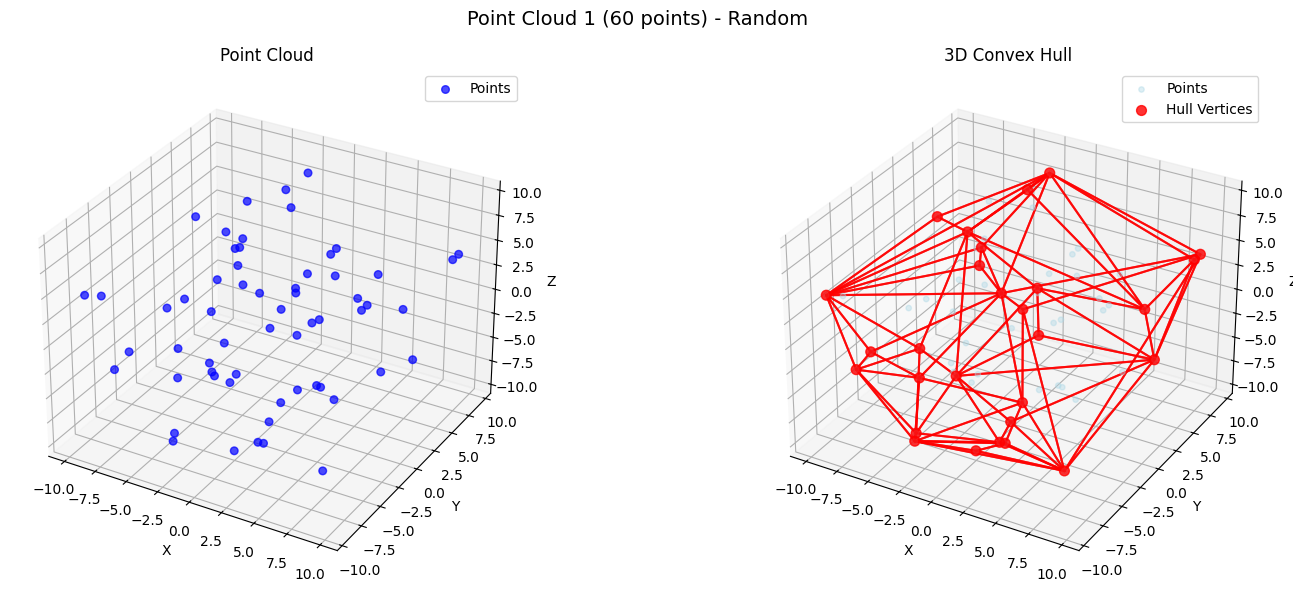

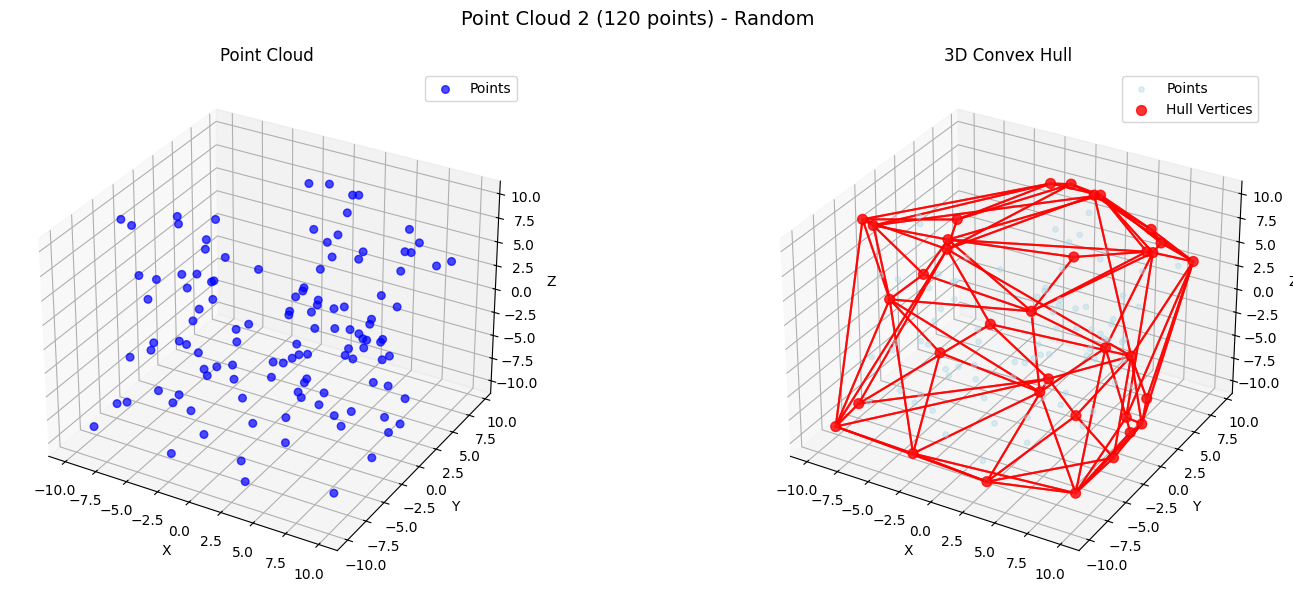

In [5]:
# Configurations for two point clouds
cloud_config_1 = RandomPointCloudConfig(
    num_points=60, lower_bound=-10.0, upper_bound=10.0
)
cloud_config_2 = RandomPointCloudConfig(
    num_points=120, lower_bound=-10.0, upper_bound=10.0
)

# Generate point clouds (with different seeds to vary points)
point_cloud_1 = generate_random_point_cloud(cloud_config_1, random_seed=RANDOM_SEED)
point_cloud_2 = generate_random_point_cloud(cloud_config_2, random_seed=RANDOM_SEED + 1)

# Convert to NumPy arrays
points_array_1 = point_cloud_to_numpy(point_cloud_1)
points_array_2 = point_cloud_to_numpy(point_cloud_2)

# Calculate custom convex hull with timing
print("=== CONVEX HULL COMPUTATION ===")
print("Computing custom convex hulls...")
start_time = time.time()
custom_hull_1 = compute_custom_convex_hull(point_cloud_1)
custom_time_1 = time.time() - start_time

start_time = time.time()
custom_hull_2 = compute_custom_convex_hull(point_cloud_2)
custom_time_2 = time.time() - start_time

# Calculate SciPy convex hull with timing
print("Computing SciPy convex hulls...")
start_time = time.time()
scipy_hull_1 = compute_scipy_convex_hull(points_array_1)
scipy_time_1 = time.time() - start_time

start_time = time.time()
scipy_hull_2 = compute_scipy_convex_hull(points_array_2)
scipy_time_2 = time.time() - start_time

# Generate detailed statistics report
print("\n" + "="*80)
print("DETAILED EXECUTION REPORT")
print("="*80)

for i, (config, custom_hull, scipy_hull, custom_time, scipy_time) in enumerate([
    (cloud_config_1, custom_hull_1, scipy_hull_1, custom_time_1, scipy_time_1),
    (cloud_config_2, custom_hull_2, scipy_hull_2, custom_time_2, scipy_time_2)
], 1):

    # Extract hull vertices for analysis
    custom_vertices = extract_custom_hull_vertices(custom_hull)

    print(f"\nPOINT CLOUD {i} STATISTICS:")
    print("-" * 40)
    print("Input Configuration:")
    print(f"- Total points: {config.num_points}")
    print(f"- Coordinate bounds: [{config.lower_bound}, {config.upper_bound}]")
    print(f"- Volume of bounding cube: {(config.upper_bound - config.lower_bound)**3:.1f}")

    print("\nCustom Hull Results:")
    print(f"- Hull vertices: {len(custom_vertices)}")
    print(f"- Hull faces: {len(custom_hull.faces)}")
    print(f"- Hull edges: {len(custom_hull.edges)}")
    print(f"- Execution time: {custom_time:.6f} seconds")
    print(f"- Vertices/second: {len(custom_vertices)/custom_time:.1f}")

    print("\nSciPy Hull Results:")
    print(f"- Hull vertices: {len(scipy_hull.vertices)}")
    print(f"- Hull faces: {len(scipy_hull.simplices)}")
    print(f"- Hull edges: {len(scipy_hull.equations)}")
    print(f"- Execution time: {scipy_time:.6f} seconds")
    print(f"- Vertices/second: {len(scipy_hull.vertices)/scipy_time:.1f}")

    # Performance comparison
    speedup = custom_time / scipy_time
    vertex_match = len(custom_vertices) == len(scipy_hull.vertices)

    print("\nPerformance Comparison:")
    print(f"- Speedup ratio (Custom/SciPy): {speedup:.2f}x")
    print(f"- Performance: {'SciPy faster' if speedup > 1 else 'Custom faster'}")
    print(f"- Vertex count match: {'Valid!' if vertex_match else 'Non valid!'}")
    print(f"- Hull complexity: {len(custom_vertices)/config.num_points:.1%} of input points")

    # Euler characteristic verification (V - E + F = 2 for convex polyhedra)
    V = len(custom_vertices)
    E = len(custom_hull.edges)
    F = len(custom_hull.faces)
    euler_char = V - E + F
    print(f"- Euler characteristic (V-E+F): {euler_char} {'Valid!' if euler_char == 2 else 'Non valid!'}")

print("\nOverall Summary:")
total_custom_time = custom_time_1 + custom_time_2
total_scipy_time = scipy_time_1 + scipy_time_2
print(f"- Total custom time: {total_custom_time:.6f}s")
print(f"- Total SciPy time: {total_scipy_time:.6f}s")
print(f"- Overall speedup: {total_custom_time/total_scipy_time:.2f}x (SciPy advantage)")
print("="*80)

# Visualize point clouds and convex hulls
print("\nGenerating visualizations...")
fig1 = plot_point_cloud_and_hull_3d(
    point_cloud_1, scipy_hull=scipy_hull_1, title="Point Cloud 1 (60 points) - Random"
)

fig2 = plot_point_cloud_and_hull_3d(
    point_cloud_2, scipy_hull=scipy_hull_2, title="Point Cloud 2 (120 points) - Random"
)

plt.show()

## 6. Exportação de figuras e arquivos STL

Nesta seção exportamos, em **uma única célula**, todos os artefatos gerados:

- Arquivos STL do fecho convexo calculado pelo algoritmo customizado.
- Figuras em PNG com a visualização do fecho convexo calculado pela SciPy.

Todos os arquivos são salvos em uma pasta com o título do trabalho e a data do dia
no formato `YYYYMMDD`. Um arquivo foi commitado para exemplificar a estrutura gerada.

In [6]:
import sys


def export_results_to_directory(
    base_title: str,
    point_clouds: dict,
    custom_hulls: dict,
    scipy_hulls: dict,
) -> Path:
    """Exports figures and STL files to a dated folder.

    Args:
        base_title: Base title for export folder name.
        point_clouds: Dictionary name -> list of points.
        custom_hulls: Dictionary name -> custom Hull.
        scipy_hulls: Dictionary name -> SciPy ConvexHull.

    Returns:
        Path to the folder where files were saved.
    """
    today_str = datetime.today().strftime("%Y%m%d")  # noqa: DTZ002
    export_dir = Path(f"{base_title}_{today_str}")
    export_dir.mkdir(parents=True, exist_ok=True)

    for cloud_name, point_cloud in point_clouds.items():
        point_cloud_to_numpy(point_cloud)

        # Export STL using custom algorithm (via print_stl)
        custom_hull = custom_hulls[cloud_name]
        old_stdout = sys.stdout
        buffer = StringIO()
        sys.stdout = buffer
        custom_hull.print_stl()
        stl_output = buffer.getvalue()
        sys.stdout = old_stdout

        stl_path = export_dir / f"{cloud_name}_custom_hull.stl"
        with stl_path.open("w", encoding="utf-8") as stl_file:
            stl_file.write(stl_output)

        # Export figure with SciPy ConvexHull
        scipy_hull = scipy_hulls[cloud_name]
        fig = plot_point_cloud_and_hull_3d(
            point_cloud,
            scipy_hull=scipy_hull,
            title=f"Convex Hull (SciPy) - {cloud_name}",
        )
        png_path = export_dir / f"{cloud_name}_scipy_hull.png"
        fig.savefig(png_path, bbox_inches="tight", dpi=150)
        plt.close(fig)

    return export_dir


# Package clouds and hulls into dictionaries
point_clouds_dict = {
    "cloud1": point_cloud_1,
    "cloud2": point_cloud_2,
}

custom_hulls_dict = {
    "cloud1": custom_hull_1,
    "cloud2": custom_hull_2,
}

scipy_hulls_dict = {
    "cloud1": scipy_hull_1,
    "cloud2": scipy_hull_2,
}

export_path = export_results_to_directory(
    base_title="convex_hull_3d",
    point_clouds=point_clouds_dict,
    custom_hulls=custom_hulls_dict,
    scipy_hulls=scipy_hulls_dict,
)

print(f"Files exported to: {export_path.resolve()}")

Files exported to: /home/gabriel/_pgms/msc/geocomp/final_project/convex_hull_3d_20251125


## 7. Simulação: comparação entre o fecho convexo customizado e o do SciPy

Por fim, executamos uma simulação que gera diversas nuvens de pontos aleatórias,
calcula o fecho convexo usando:

- A implementação customizada (`Hull`),
- A implementação da SciPy (`ConvexHull`),

e compara:

- Quantidade de vértices no fecho convexo.
- Se o conjunto de vértices coincide (dentro de uma tolerância numérica).
- **Tempo de execução** de ambos os algoritmos.

Isso ajuda a validar empiricamente a corretude da implementação customizada e
analisar sua performance comparativa.

=== COMPARISON RESULTS ===
Exp  Points  Custom V  SciPy V  Match  Custom T   SciPy T   
----------------------------------------------------------------------
1    80      29        29       1      0.0095     0.0005    
2    80      31        31       1      0.0096     0.0005    
3    80      31        31       1      0.0111     0.0004    
4    80      26        26       1      0.0079     0.0003    
5    80      33        33       1      0.0092     0.0003    

=== PERFORMANCE SUMMARY ===
Custom Implementation:
- Average time: 0.0094s ± 0.0010s
- Min time: 0.0079s
- Max time: 0.0111s

SciPy Implementation:
- Average time: 0.0004s ± 0.0001s
- Min time: 0.0003s
- Max time: 0.0005s

Speedup ratio (Custom/SciPy): 24.92x


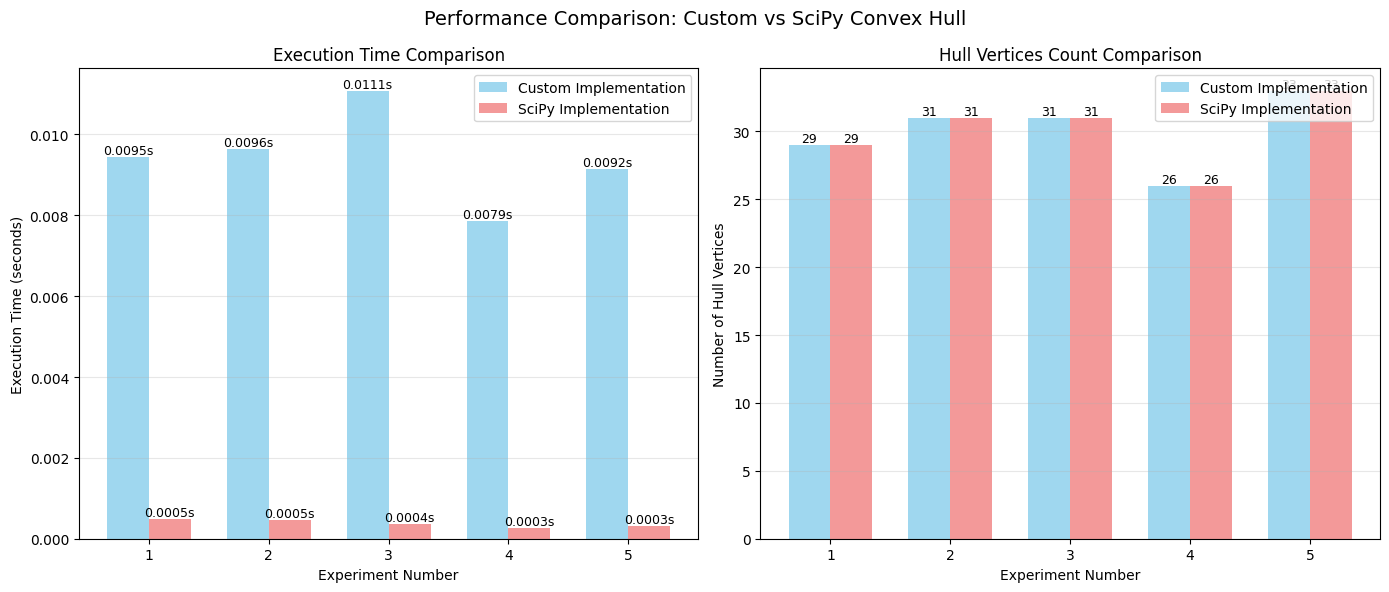

In [7]:
def run_convex_hull_comparison_experiment(
    num_experiments: int = 5,
    num_points_per_experiment: int = 80,
    lower_bound: float = -10.0,
    upper_bound: float = 10.0,
    base_random_seed: int = RANDOM_SEED,
) -> list:
    """Executes a series of experiments comparing Hull (custom) and SciPy.

    Args:
        num_experiments: Number of experiments to execute.
        num_points_per_experiment: Number of points in each cloud.
        lower_bound: Lower bound for coordinates.
        upper_bound: Upper bound for coordinates.
        base_random_seed: Base seed for point generation.

    Returns:
        List of comparison results between both algorithms.
    """
    results: list = []

    for experiment_index in range(num_experiments):
        experiment_seed = base_random_seed + experiment_index

        config = RandomPointCloudConfig(
            num_points=num_points_per_experiment,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
        )
        point_cloud = generate_random_point_cloud(config, random_seed=experiment_seed)
        points_array = point_cloud_to_numpy(point_cloud)

        # Calculate convex hulls with timing
        start_time = time.time()
        custom_hull = compute_custom_convex_hull(point_cloud)
        custom_execution_time = time.time() - start_time

        start_time = time.time()
        scipy_hull = compute_scipy_convex_hull(points_array)
        scipy_execution_time = time.time() - start_time

        # Extract vertices
        custom_vertices = extract_custom_hull_vertices(custom_hull)
        scipy_vertices = points_array[scipy_hull.vertices]

        # Sort for deterministic comparison
        custom_sorted = custom_vertices[
            np.lexsort(
                (custom_vertices[:, 2], custom_vertices[:, 1], custom_vertices[:, 0])
            )
        ]
        scipy_sorted = scipy_vertices[
            np.lexsort(
                (scipy_vertices[:, 2], scipy_vertices[:, 1], scipy_vertices[:, 0])
            )
        ]

        same_shape = custom_sorted.shape == scipy_sorted.shape
        vertices_match = False
        if same_shape:
            vertices_match = np.allclose(custom_sorted, scipy_sorted, atol=1e-6)

        result = ConvexHullComparisonResult(
            num_points=num_points_per_experiment,
            num_vertices_custom=int(custom_vertices.shape[0]),
            num_vertices_scipy=int(scipy_vertices.shape[0]),
            vertices_match=bool(vertices_match),
            custom_execution_time=float(custom_execution_time),
            scipy_execution_time=float(scipy_execution_time),
        )
        results.append(result)

    return results


# Run comparison experiments
comparison_results = run_convex_hull_comparison_experiment(
    num_experiments=5,
    num_points_per_experiment=80,
)

# Print results summary
print("=== COMPARISON RESULTS ===")
print(
    f"{'Exp':<4} {'Points':<7} {'Custom V':<9} {'SciPy V':<8} {'Match':<6} {'Custom T':<10} {'SciPy T':<10}"
)
print("-" * 70)

for index, result in enumerate(comparison_results, start=1):
    print(
        f"{index:<4} {result.num_points:<7} {result.num_vertices_custom:<9} "
        f"{result.num_vertices_scipy:<8} {result.vertices_match:<6} "
        f"{result.custom_execution_time:<10.4f} {result.scipy_execution_time:<10.4f}"
    )

# Calculate and display summary statistics
custom_times = [r.custom_execution_time for r in comparison_results]
scipy_times = [r.scipy_execution_time for r in comparison_results]

print("\n=== PERFORMANCE SUMMARY ===")
print("Custom Implementation:")
print(f"- Average time: {np.mean(custom_times):.4f}s ± {np.std(custom_times):.4f}s")
print(f"- Min time: {np.min(custom_times):.4f}s")
print(f"- Max time: {np.max(custom_times):.4f}s")

print("\nSciPy Implementation:")
print(f"- Average time: {np.mean(scipy_times):.4f}s ± {np.std(scipy_times):.4f}s")
print(f"- Min time: {np.min(scipy_times):.4f}s")
print(f"- Max time: {np.max(scipy_times):.4f}s")

speedup_ratio = np.mean(custom_times) / np.mean(scipy_times)
print(f"\nSpeedup ratio (Custom/SciPy): {speedup_ratio:.2f}x")

performance_fig = plot_performance_comparison(
    comparison_results, title="Performance Comparison: Custom vs SciPy Convex Hull"
)
plt.show()